In [89]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [90]:
df = pd.read_csv('../DATA/Telco-Customer-Churn.csv')

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [92]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [93]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [94]:
features = df.columns
features

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [95]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Here we will discover how many unique values are in each column

In [96]:
uniqueness = pd.DataFrame(index=features)
uniqueness['nunique'] = df.nunique()
uniqueness

,nunique
customerID,7032
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,72
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


We see that customerID, tenure, MonthlyCharges and TotalCharges are numeric, while the other features, including the target feature(Churn), are categorical. So, the task is classification

Let's see what values categorical attributes take on

In [97]:
categorical_df = df.drop(['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges'], axis=1)
cat_unique = {}
for feature in categorical_df.columns:
    cat_unique[feature] = categorical_df[feature].unique()

cat_unique_df = pd.DataFrame.from_dict(cat_unique, orient='index').transpose()
cat_unique_df

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,1,No,Yes,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,One year,No,Mailed check,Yes
2,None,None,None,None,None,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,None,Bank transfer (automatic),None
3,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Credit card (automatic),None


It is time for EDA

<Axes: xlabel='Churn', ylabel='count'>

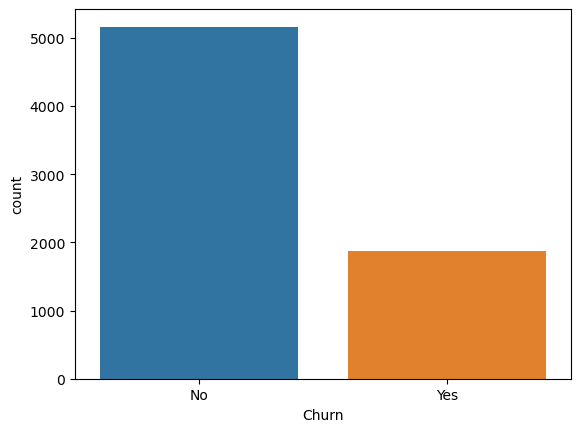

In [98]:
sns.countplot(data=df, x='Churn')

<Axes: xlabel='Churn', ylabel='TotalCharges'>

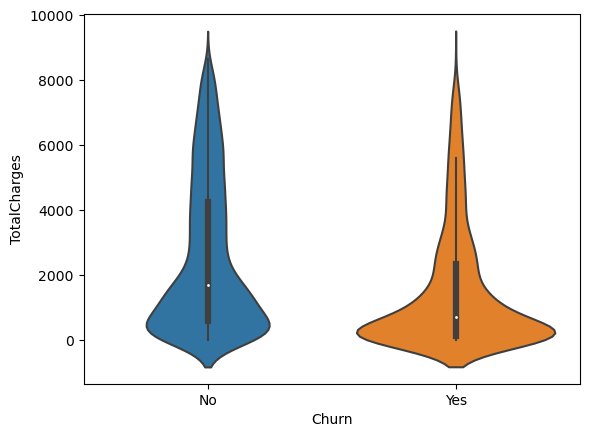

In [99]:
sns.violinplot(data=df, x='Churn', y='TotalCharges')

<Axes: xlabel='Contract', ylabel='TotalCharges'>

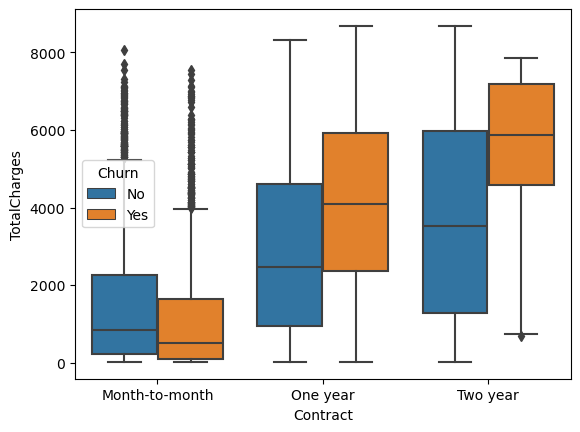

In [100]:
sns.boxplot(data=df, hue='Churn', y='TotalCharges', x='Contract')


It is noticible that the median of TotalCharges increases with the increase of duration of the contracts

The next step will be to explore the correlations between features and the target

In [101]:
dummy_df = pd.get_dummies(df[['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'MultipleLines', 
     'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'InternetService',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']], drop_first=True)

In [102]:
corr_df = dummy_df.corr()

In [103]:
target_corr = corr_df['Churn_Yes'].drop('Churn_Yes').sort_values()
target_corr

Contract_Two year                       -0.301552
TechSupport_No internet service         -0.227578
StreamingMovies_No internet service     -0.227578
OnlineSecurity_No internet service      -0.227578
OnlineBackup_No internet service        -0.227578
StreamingTV_No internet service         -0.227578
DeviceProtection_No internet service    -0.227578
InternetService_No                      -0.227578
Contract_One year                       -0.178225
OnlineSecurity_Yes                      -0.171270
TechSupport_Yes                         -0.164716
Dependents_Yes                          -0.163128
Partner_Yes                             -0.149982
PaymentMethod_Credit card (automatic)   -0.134687
PaymentMethod_Mailed check              -0.090773
OnlineBackup_Yes                        -0.082307
DeviceProtection_Yes                    -0.066193
MultipleLines_No phone service          -0.011691
gender_Male                             -0.008545
PhoneService_Yes                         0.011691


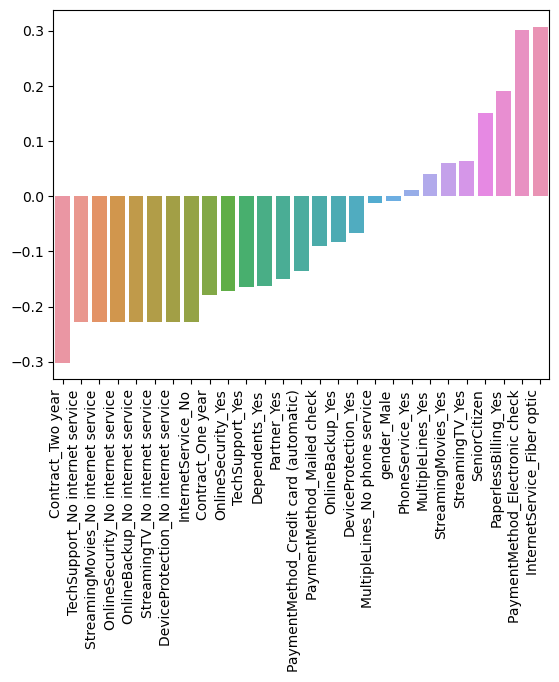

In [104]:

ax = sns.barplot(x=target_corr.index, y=target_corr.values)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right");

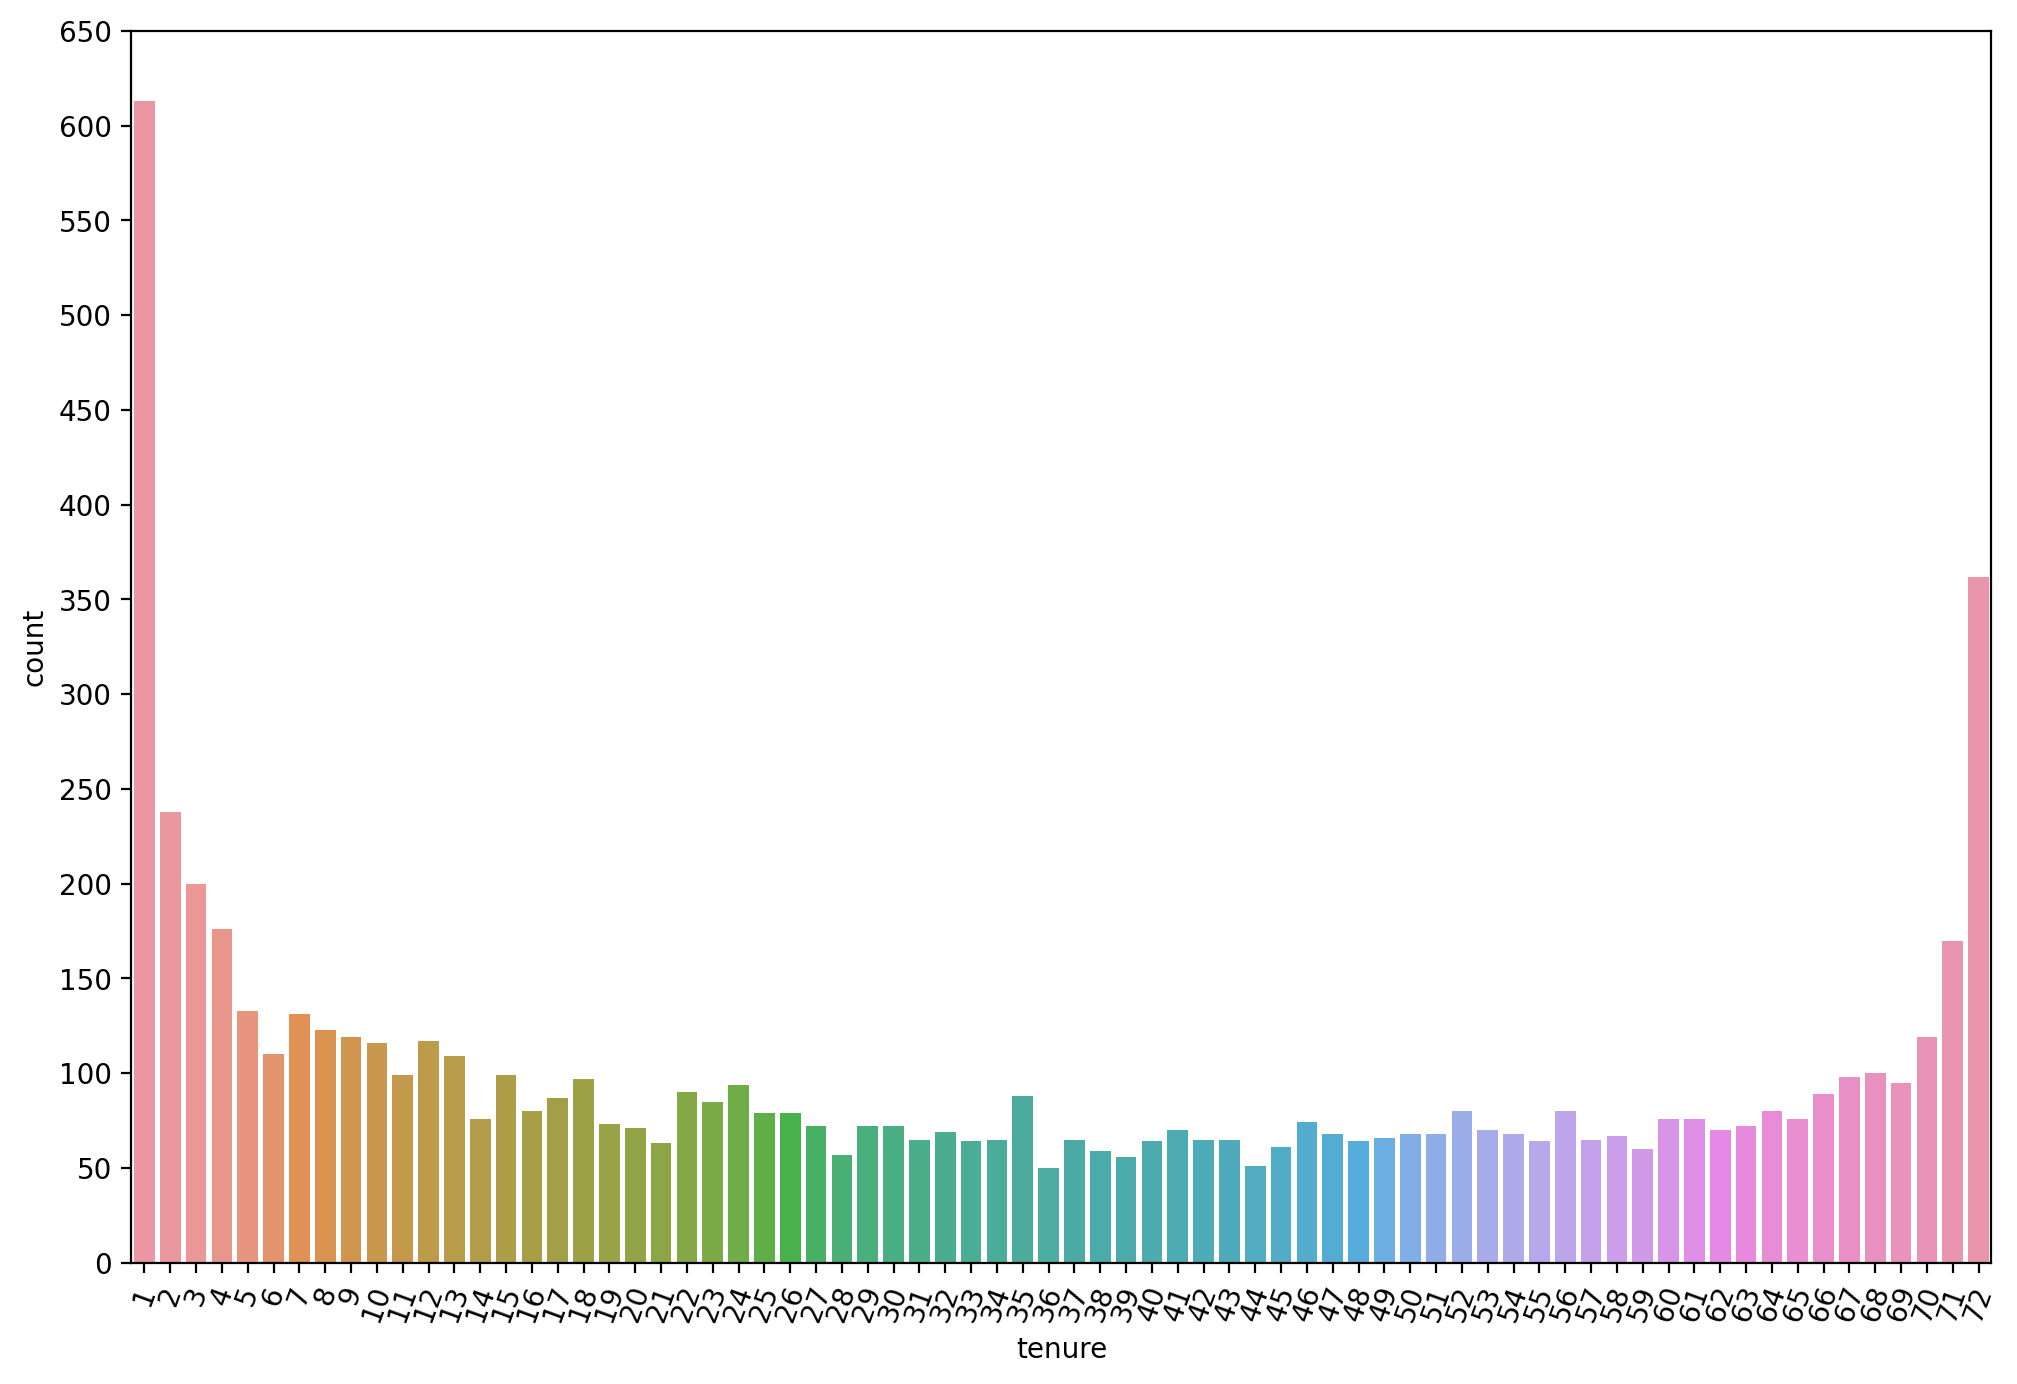

In [105]:
plt.figure(figsize=(12,8), dpi=200)
plot = sns.countplot(data=df, x='tenure')
plot.set_xticklabels(plot.get_xticklabels(), rotation=70)
plot.set_yticks(range(0,700,50));


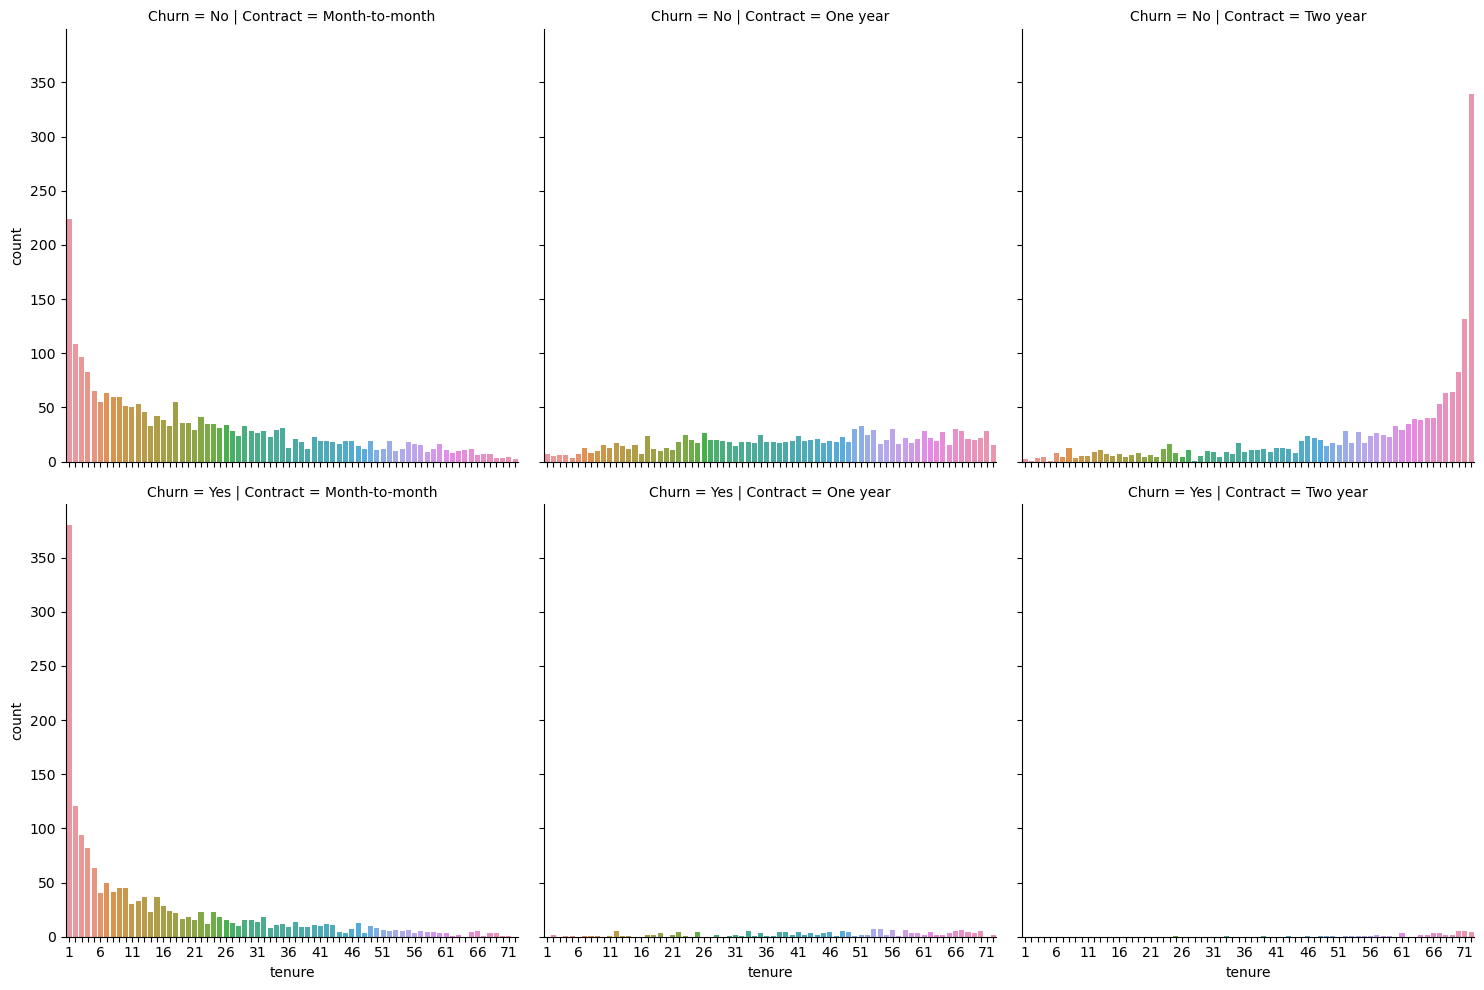

In [106]:
plot = sns.catplot(data=df, x='tenure', row='Churn', col='Contract', kind='count')

plot.set_xticklabels([str(i) if i % 5 == 1 else '' for i in range(1, 73)])

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

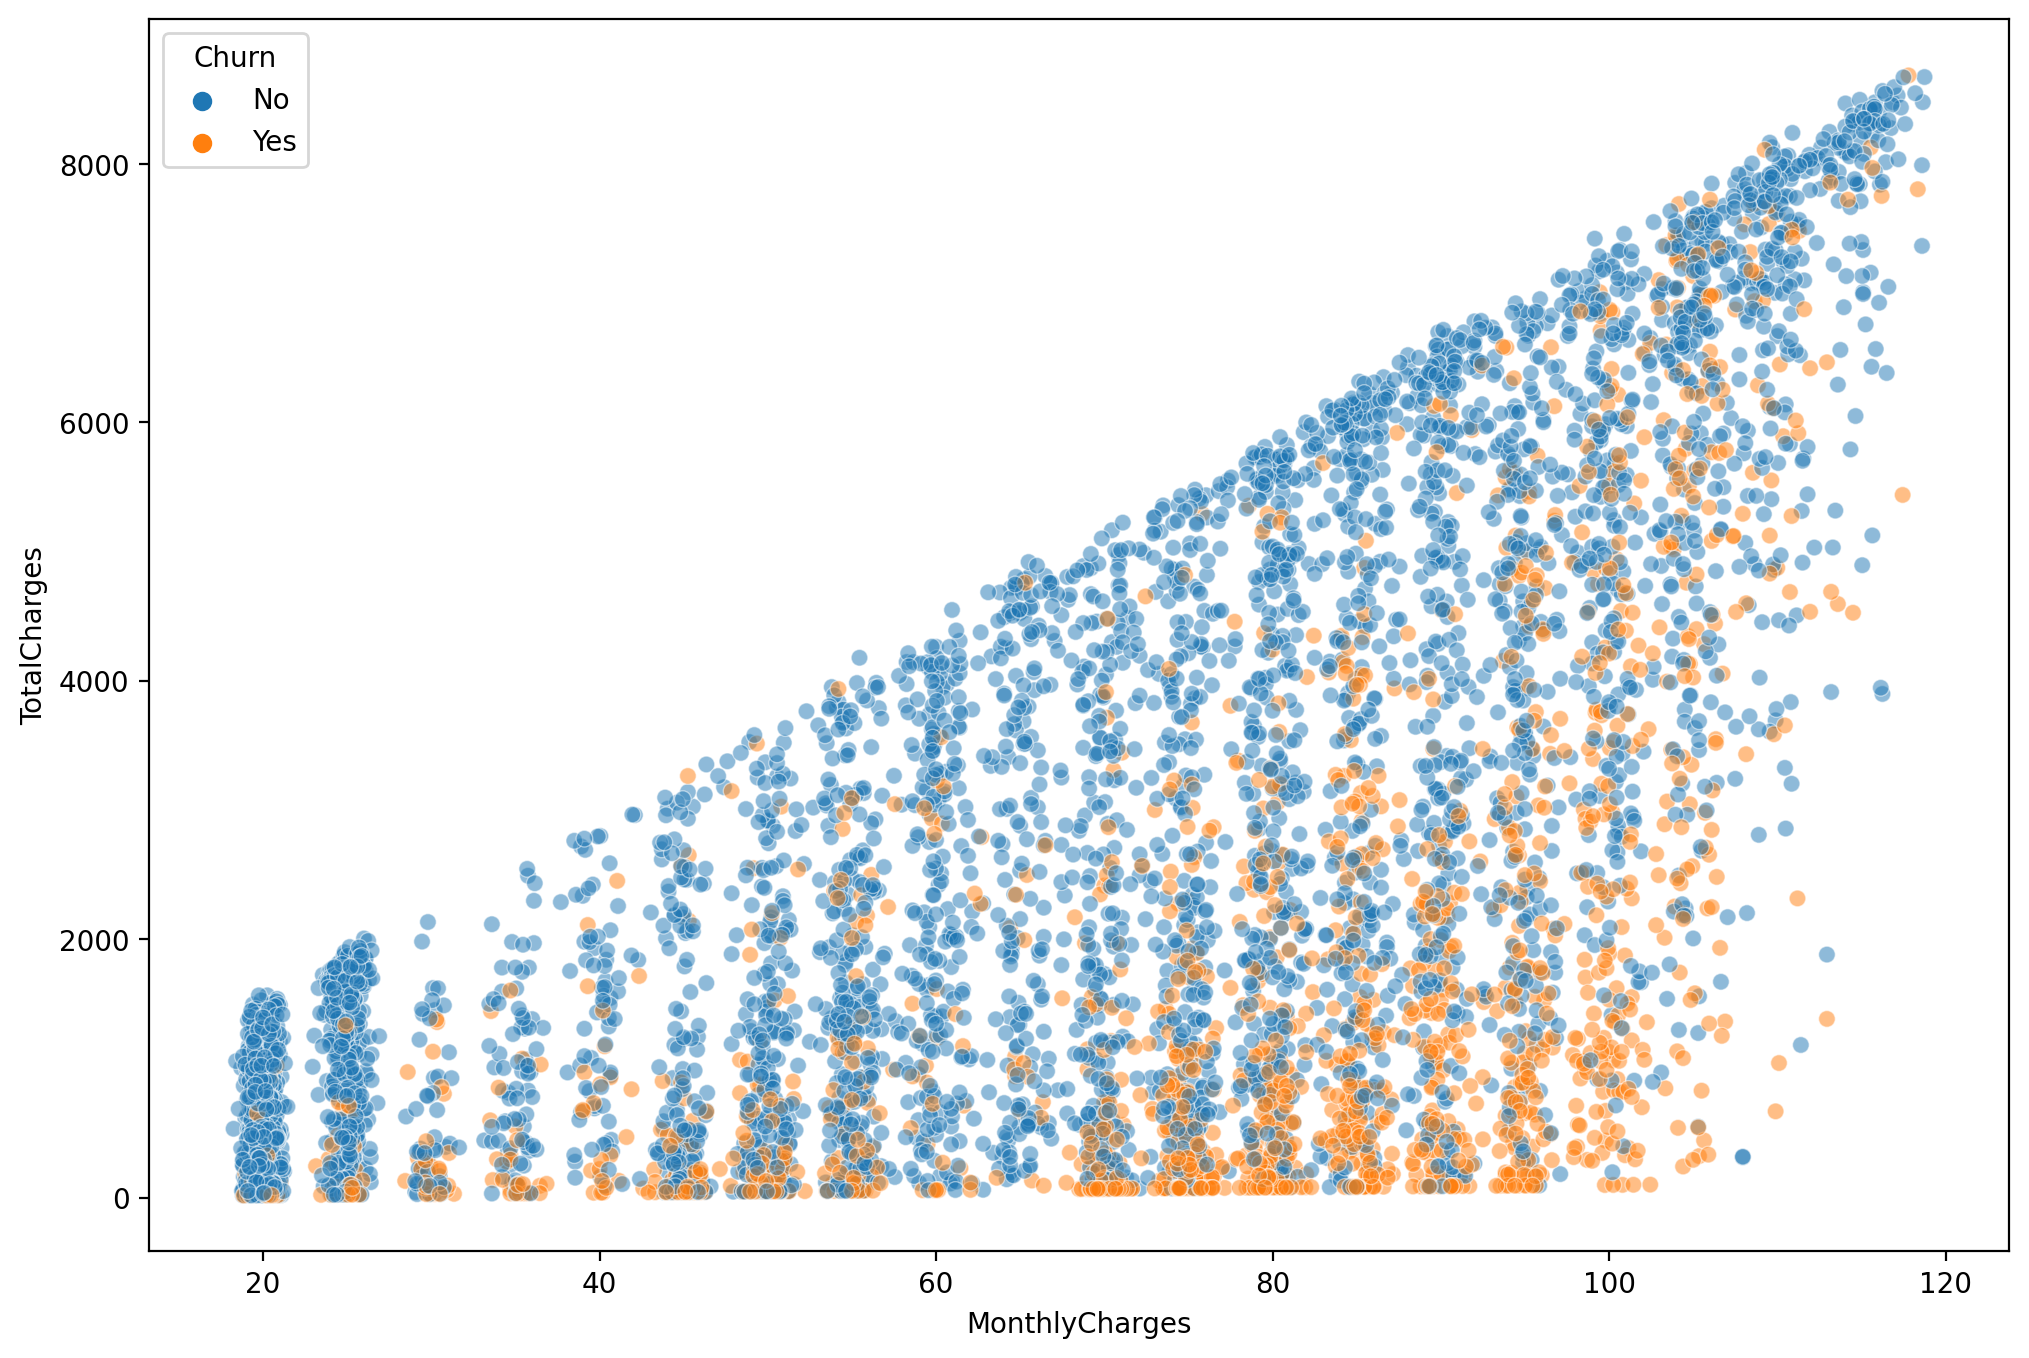

In [107]:
plt.figure(figsize=(12, 8), dpi=200)
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', hue='Churn', alpha=0.5)

Let's analyse data divided by tenure into cohorts

In [108]:
def calculate_percentage_of_yes(series: pd.Series) -> np.float64:
    """ Calculates the percentage of 'Yes' values in a Pandas Series. """

    ser = series == 'Yes'
    return ser.mean() * 100


churn_rate_by_tenure = df.groupby('tenure')[['Churn']].apply(lambda x: calculate_percentage_of_yes(x))
churn_rate_by_tenure


,Churn
tenure,
1,61.990212
2,51.680672
3,47.000000
4,47.159091
5,48.120301
...,...
68,9.000000
69,8.421053
70,9.243697


Text(0.5, 1.0, 'Churn rate by tenure')

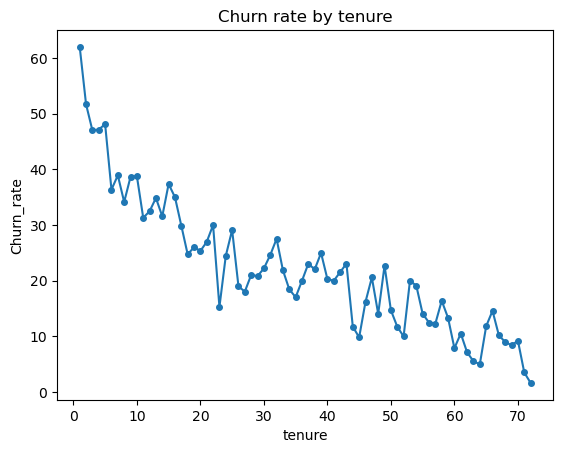

In [109]:
plt.plot(churn_rate_by_tenure.index, churn_rate_by_tenure['Churn'], marker='o', markersize=4)
plt.xlabel('tenure')
plt.ylabel('Churn_rate')
plt.title('Churn rate by tenure')

The next step will be to create 4 cohorts of tenure: 0-12 month, 13-24 months, 25-48 months and over than 48 months

In [110]:
conditions = [
    (df['tenure'] <= 12),
    (df['tenure'] > 12) & (df['tenure'] <= 24),
    (df['tenure'] > 24) & (df['tenure'] <= 48),
    (df['tenure'] > 48)
]

values = ['0-12 months', '13-24 months', '25-48 months', 'over 48 months']

df['TenureCohort'] = np.select(conditions, values, default=-1)
df['TenureCohort']

0          0-12 months
1         25-48 months
2          0-12 months
3         25-48 months
4          0-12 months
             ...      
7027      13-24 months
7028    over 48 months
7029       0-12 months
7030       0-12 months
7031    over 48 months
Name: TenureCohort, Length: 7032, dtype: object

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

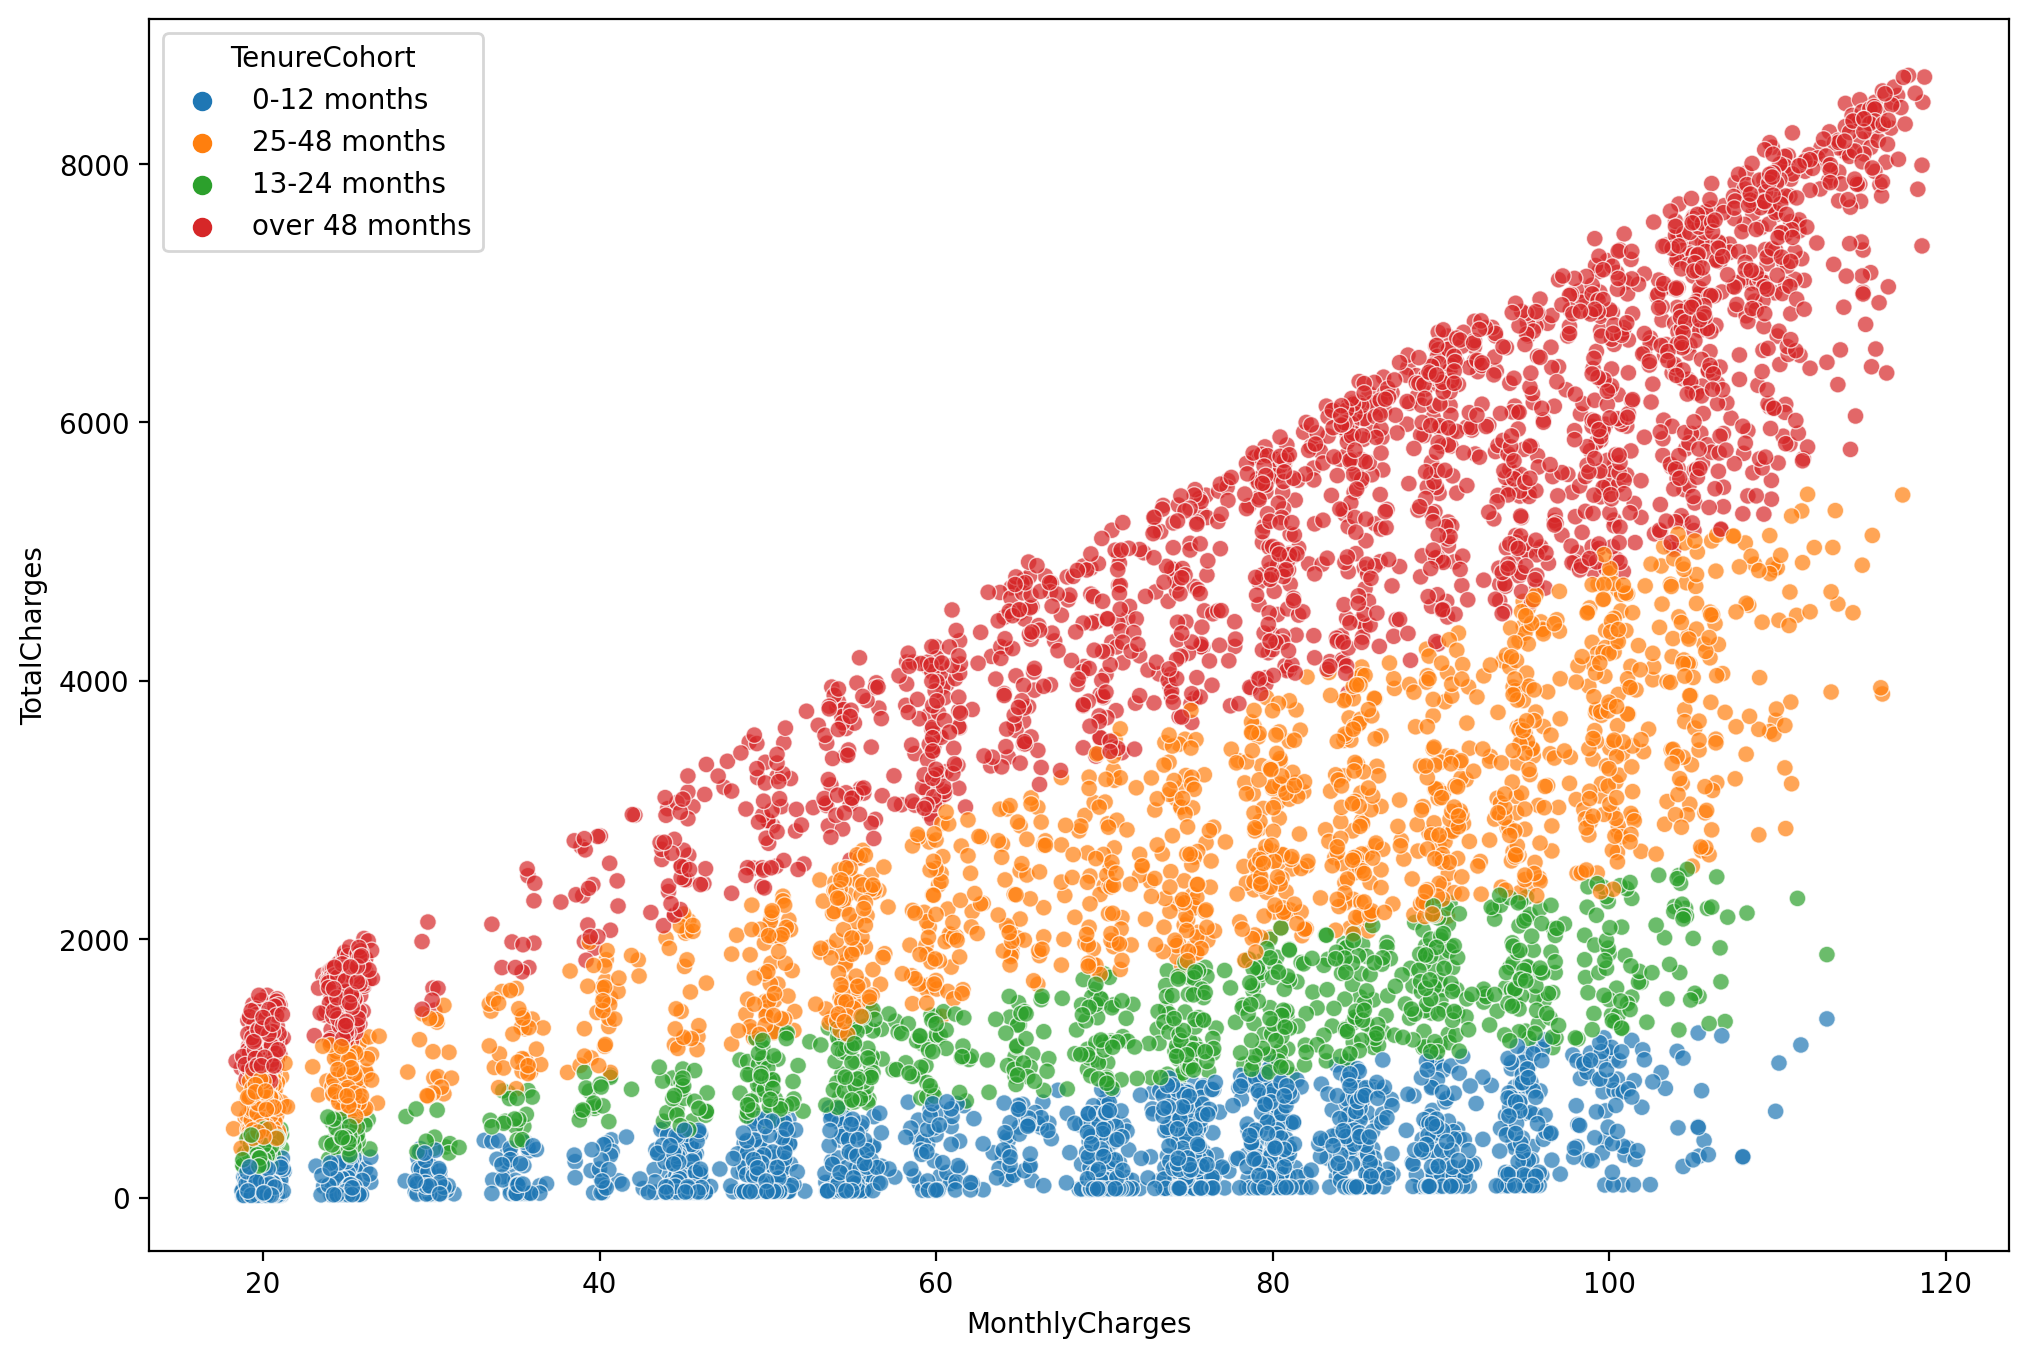

In [111]:
plt.figure(figsize=(12, 8), dpi=200)
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', hue='TenureCohort', alpha=0.7)

<Axes: xlabel='TenureCohort', ylabel='count'>

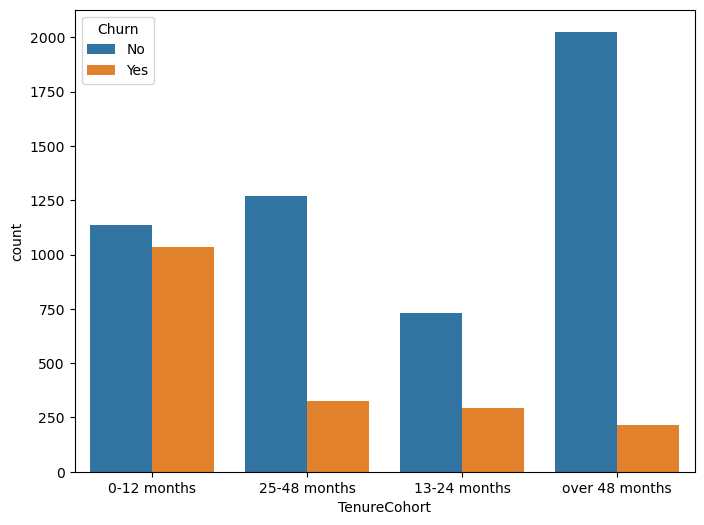

In [112]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='TenureCohort', hue='Churn')

We have explored the data. It is time to test some models on predicting whether the loan would be returned or not. At first, I will not exclude outliers. If later the results of the models will be bad, i will be dealing with outliers.

So, let's split our data into X_train, y_train, X_test and y_test

In [113]:
from sklearn.model_selection import train_test_split


In [114]:
X = df.drop(['Churn','customerID'],axis=1)
X = pd.get_dummies(X,drop_first=True)
y = df['Churn']


In [115]:
X

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureCohort_13-24 months,TenureCohort_25-48 months,TenureCohort_over 48 months
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,True,False,True,False,False,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,True,False,False,False,False,True,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,True,False,False,True,False,False,False
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,24,84.80,1990.50,True,True,True,True,False,True,...,True,True,False,True,False,False,True,True,False,False
7028,0,72,103.20,7362.90,False,True,True,True,False,True,...,True,True,False,True,True,False,False,False,False,True
7029,0,11,29.60,346.45,False,True,True,False,True,False,...,False,False,False,True,False,True,False,False,False,False
7030,1,4,74.40,306.60,True,True,False,True,False,True,...,False,False,False,True,False,False,True,False,False,False


In [116]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [117]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_X_train = X_train.copy()
scaled_X_train[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(X_train[['tenure', 'MonthlyCharges', 'TotalCharges']])
scaled_X_train

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureCohort_13-24 months,TenureCohort_25-48 months,TenureCohort_over 48 months
2273,1,-1.030108,-0.551243,-0.852185,False,False,False,True,False,False,...,False,False,False,True,False,True,False,False,False,False
3739,0,-1.030108,0.977526,-0.707287,True,False,False,True,False,False,...,True,False,False,True,False,True,False,False,False,False
4480,1,0.393452,0.310246,0.421563,False,True,False,True,False,False,...,False,False,False,True,True,False,False,False,True,False
6098,0,-1.274147,-1.489087,-0.993446,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
1498,1,0.515472,1.239791,1.085519,False,False,False,True,False,True,...,True,True,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599,0,-0.664050,0.323525,-0.486182,True,False,False,True,False,False,...,False,False,False,True,True,False,False,True,False,False
5695,0,-0.542030,0.731861,-0.312516,False,True,False,True,False,True,...,False,False,False,True,False,True,False,True,False,False
1361,0,-0.908088,0.690363,-0.643424,True,True,False,True,False,True,...,False,False,False,True,False,True,False,False,False,False
1547,0,-0.053952,0.522713,0.087458,False,True,True,True,False,True,...,True,False,True,False,False,False,False,False,True,False


In [118]:
y_train

2273     No
3739    Yes
4480    Yes
6098     No
1498     No
       ... 
599      No
5695     No
1361    Yes
1547     No
4959    Yes
Name: Churn, Length: 6328, dtype: object

In [119]:
from sklearn.linear_model import LogisticRegression

In [150]:
log_model = LogisticRegression()
log_model.fit(scaled_X_train, y_train)

c:\Users\aleks\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [151]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score

In [152]:
y_pred = log_model.predict(X_test)

In [123]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

          No       0.02      0.60      0.03        15
         Yes       0.96      0.20      0.34       689

    accuracy                           0.21       704
   macro avg       0.49      0.40      0.18       704
weighted avg       0.94      0.21      0.33       704



KNN

In [124]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier()

In [125]:
param_grid = {'n_neighbors': [1, 2, 3, 5, 10, 25, 50, 100]}
from sklearn.model_selection import GridSearchCV
grid_model = GridSearchCV(knn_model, param_grid=param_grid)

In [126]:
grid_model.fit(X_train, y_train)

GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 2, 3, 5, 10, 25, 50, 100]})

In [ ]:
grid_model.best_params_

{'n_neighbors': 10}

In [128]:
param_grid = {'n_neighbors': [10, 15, 20, 25, 30, 35, 40, 45, 50]}
grid_model_knn = GridSearchCV(knn_model, param_grid=param_grid)

In [129]:
grid_model_knn.fit(X_train, y_train)

GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [10, 15, 20, 25, 30, 35, 40, 45, 50]})

In [130]:
grid_model_knn.best_params_

{'n_neighbors': 20}

In [154]:
y_pred = grid_model_knn.predict(X_test)

In [132]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

          No       0.93      0.84      0.88       613
         Yes       0.35      0.56      0.43        91

    accuracy                           0.81       704
   macro avg       0.64      0.70      0.66       704
weighted avg       0.85      0.81      0.82       704



In [158]:
best_model_scores = {} # - a dict for best results of each model
best_model_scores['KNN'] = grid_model_knn.best_score_

The next model that i will try will be SVM

In [133]:
from sklearn.svm import SVC
svc = SVC()


In [134]:
param_grid_svm = {'kernel': ['rbf', 'sigmoid'], 'C': [0.005, 0.01, 1, 10, 100]}
grid_model_svm = GridSearchCV(svc, param_grid=param_grid_svm, verbose=4)

In [135]:
grid_model_svm.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END ...............C=0.005, kernel=rbf;, score=0.728 total time=   2.1s
[CV 2/5] END ...............C=0.005, kernel=rbf;, score=0.727 total time=   2.2s
[CV 3/5] END ...............C=0.005, kernel=rbf;, score=0.727 total time=   2.2s
[CV 4/5] END ...............C=0.005, kernel=rbf;, score=0.728 total time=   2.2s
[CV 5/5] END ...............C=0.005, kernel=rbf;, score=0.728 total time=   2.3s
[CV 1/5] END ...........C=0.005, kernel=sigmoid;, score=0.728 total time=   0.8s
[CV 2/5] END ...........C=0.005, kernel=sigmoid;, score=0.727 total time=   1.0s
[CV 3/5] END ...........C=0.005, kernel=sigmoid;, score=0.727 total time=   0.9s
[CV 4/5] END ...........C=0.005, kernel=sigmoid;, score=0.728 total time=   0.9s
[CV 5/5] END ...........C=0.005, kernel=sigmoid;, score=0.728 total time=   0.9s
[CV 1/5] END ................C=0.01, kernel=rbf;, score=0.728 total time=   2.4s
[CV 2/5] END ................C=0.01, kernel=rbf;

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.005, 0.01, 1, 10, 100],
                         'kernel': ['rbf', 'sigmoid']},
             verbose=4)

In [136]:
grid_model_svm.best_params_

{'C': 100, 'kernel': 'rbf'}

In [137]:
y_pred = grid_model_svm.predict(X_test)

In [138]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

          No       0.94      0.84      0.89       621
         Yes       0.33      0.59      0.43        83

    accuracy                           0.81       704
   macro avg       0.64      0.72      0.66       704
weighted avg       0.87      0.81      0.83       704



In [161]:
best_model_scores['SVC'] = grid_model_svm.best_score_

RandomForestClassifier

In [139]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()

In [140]:
param_grid_rfc = {'n_estimators': [32, 64, 128, 256], 'bootstrap': [True, False]}
grid_model_rfc = GridSearchCV(rfc, param_grid=param_grid_rfc, verbose=10)

In [141]:
grid_model_rfc.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV 1/5; 1/8] START bootstrap=True, n_estimators=32.............................
[CV 1/5; 1/8] END bootstrap=True, n_estimators=32;, score=0.784 total time=   0.2s
[CV 2/5; 1/8] START bootstrap=True, n_estimators=32.............................
[CV 2/5; 1/8] END bootstrap=True, n_estimators=32;, score=0.783 total time=   0.2s
[CV 3/5; 1/8] START bootstrap=True, n_estimators=32.............................
[CV 3/5; 1/8] END bootstrap=True, n_estimators=32;, score=0.774 total time=   0.3s
[CV 4/5; 1/8] START bootstrap=True, n_estimators=32.............................
[CV 4/5; 1/8] END bootstrap=True, n_estimators=32;, score=0.764 total time=   0.2s
[CV 5/5; 1/8] START bootstrap=True, n_estimators=32.............................
[CV 5/5; 1/8] END bootstrap=True, n_estimators=32;, score=0.798 total time=   0.2s
[CV 1/5; 2/8] START bootstrap=True, n_estimators=64.............................
[CV 1/5; 2/8] END bootstrap=True, n_est

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False],
                         'n_estimators': [32, 64, 128, 256]},
             verbose=10)

In [142]:
grid_model_rfc.best_params_

{'bootstrap': True, 'n_estimators': 128}

In [144]:
grid_model_rfc.best_score_

0.7882421994517606

In [159]:
best_model_scores['RandomForestClassifier'] = grid_model_svm.best_score_

AdaBoost

In [169]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
adc = AdaBoostClassifier()

In [164]:
adc.fit(X_train, y_train)

AdaBoostClassifier()

In [166]:
y_pred = adc.predict(X_test)

In [167]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

          No       0.90      0.88      0.89       571
         Yes       0.54      0.60      0.57       133

    accuracy                           0.83       704
   macro avg       0.72      0.74      0.73       704
weighted avg       0.84      0.83      0.83       704



In [170]:
errors = []
for n in range(1, 100):
    adc = AdaBoostClassifier(n_estimators=n)
    adc.fit(X_train, y_train)
    preds = adc.predict(X_test)
    err = 1 - accuracy_score(y_test, preds)
    errors.append(err)

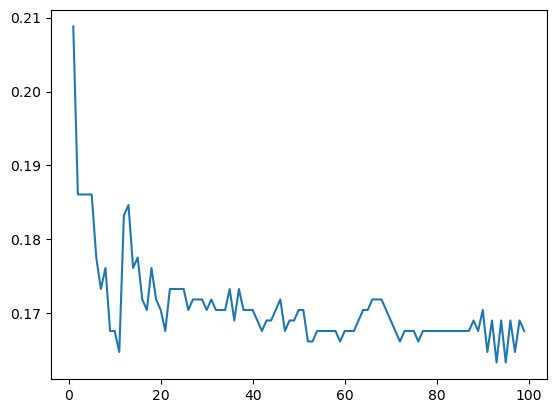

In [171]:
plt.plot(range(1,100), errors)

In [172]:
best_adc = AdaBoostClassifier(n_estimators=50)

In [173]:
best_adc.fit(X_train, y_train)

AdaBoostClassifier()

In [174]:
y_pred = best_adc.predict(X_test)

In [175]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

          No       0.90      0.88      0.89       571
         Yes       0.54      0.60      0.57       133

    accuracy                           0.83       704
   macro avg       0.72      0.74      0.73       704
weighted avg       0.84      0.83      0.83       704



In [177]:
from sklearn.metrics import f1_score
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
weighted_f1

0.8263418762088975

In [178]:
best_model_scores['AdaBoostClassifier'] = weighted_f1

GradientBoostingClassifier

In [179]:
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier()

In [180]:
param_grid_gbc = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 10, 20]
}

In [182]:
grid_model_gbc = GridSearchCV(gbc, param_grid=param_grid_gbc, verbose=5)

In [183]:
grid_model_gbc.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV 1/5] END learning_rate=0.01, max_depth=3, min_samples_split=2, n_estimators=100;, score=0.784 total time=   1.1s
[CV 2/5] END learning_rate=0.01, max_depth=3, min_samples_split=2, n_estimators=100;, score=0.777 total time=   0.8s
[CV 3/5] END learning_rate=0.01, max_depth=3, min_samples_split=2, n_estimators=100;, score=0.781 total time=   0.7s
[CV 4/5] END learning_rate=0.01, max_depth=3, min_samples_split=2, n_estimators=100;, score=0.760 total time=   0.9s
[CV 5/5] END learning_rate=0.01, max_depth=3, min_samples_split=2, n_estimators=100;, score=0.779 total time=   0.8s
[CV 1/5] END learning_rate=0.01, max_depth=3, min_samples_split=2, n_estimators=200;, score=0.789 total time=   1.7s
[CV 2/5] END learning_rate=0.01, max_depth=3, min_samples_split=2, n_estimators=200;, score=0.799 total time=   1.8s
[CV 3/5] END learning_rate=0.01, max_depth=3, min_samples_split=2, n_estimators=200;, score=0.795 total time=   1.5s
[C

GridSearchCV(estimator=GradientBoostingClassifier(),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 4, 5],
                         'min_samples_split': [2, 10, 20],
                         'n_estimators': [100, 200, 300]},
             verbose=5)

In [184]:
grid_model_gbc.best_params_

{'learning_rate': 0.1,
 'max_depth': 3,
 'min_samples_split': 10,
 'n_estimators': 100}

In [185]:
grid_model_gbc.best_score_

0.8019916452803326

In [186]:
best_model_scores['GradientBoostingClassifier'] = grid_model_gbc.best_score_

In [203]:
best_model_ser = pd.Series(best_model_scores)
best_model_ser

KNN                           0.777022
RandomForestClassifier        0.780023
SVC                           0.780023
AdaBoostClassifier            0.826342
GradientBoostingClassifier    0.801992
dtype: float64